# Homework 5 | CFRM 505 | Revtsov

In [1]:
import numpy as np
from scipy.stats import norm, gmean
from scipy.special import factorial

import matplotlib.pyplot as plt

# Problem 1

A vanilla European put option on an underlying asset is a financial instrument granting the holder the right (but not the obligation) to buy a unit of the asset at time $T$ for price $K$.  If we let $\{S_t\}$ be the price process of the underlying asset, then the payoff of this option is $\max\{K - S_T,\, 0\}$.  The value of this option at time $t=0$ is given by

$$P_0 = e^{-rT}\mathbb{E}\left[\max\{K - S_T,\, 0\}\right],$$

where the expected value is taken with respect to the risk-neutral measure.  Working with the risk-neutral measure can be complicated, but is made much simpler if we assume that the price of the underlying asset follows a geometric Brownian motion.  Under this assumption, the value of the option is

$$P_0 = e^{-rT}\mathbb{E}\left[\max\{K - S_T,\, 0\}\right],$$

with the usual expected value, but where $\{S_t\}\sim\textrm{GBM}(r, \sigma)$.  Notice the key difference here: The price process is assumed to have a drift parameter of $r$, the risk-free rate, rather than some arbitrary parameter $\mu$ that depends on the asset.

Consider a vanilla European put option with $K = 100$, $T = 0.5$, $S_0 = 92$, $r = 0.05$ and $\sigma = 0.05$.

## Part a

What method should you use to simulate $S_T$?  Can you get an exact simulation?  Do you have to simulate $S_t$ at any other times besides $T$?

## Part b

Simulate at least $100,000$ i.i.d. samples of the payoff $\max\{K - S_T,\, 0\}$.  Plot a histogram of these payoffs.

## Part c

Using your simulations from part (b), estimate the value of the option $P_0$.

## Part d

One can derive an exact formula for the value of a vanilla European Put option (through the Black-Scholes formula).  In particular,

$$P_0 = Ke^{-rT}F_Z(-d_2) - S_0F_Z(-d_1),$$

where

$$d_1 = \frac{\ln(S_0 / K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}},$$

and

$$d_2 = d_1 - \sigma\sqrt{T}.$$

(Here, $F_Z$ is the cdf of the standard normal distribution.)

What is the absolute error of your estimate from part (c)?  What is the relative error?

### Solution

#### Part a

Since $\{S_t\} \sim \text{GBM}(r, \sigma)$, the price at any time $T$ has a known closed-form distribution:

$$S_T = S_0 \exp\left(\left(r - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T}\, Z\right), \quad Z \sim N(0,1)$$

This allows an exact simulation: draw $Z \sim N(0,1)$ and apply the formula directly. No discretization or approximation is needed. Since the payoff $\max\{K - S_T, 0\}$ depends only on $S_T$, there is no need to simulate $S_t$ at any intermediate times.

#### Part b

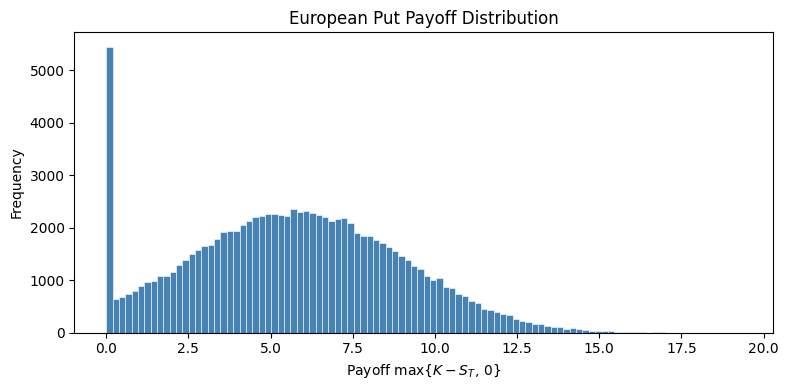

In [2]:
N = 100_000
K = 100
T = 0.5
s_0 = 92
r = 0.05
sigma = 0.05

def s_t_gmb(s_0, mu, sigma, d_t):
    z = np.random.normal(0, 1)
    return s_0 * np.exp((mu - (sigma**2)/2)*d_t + sigma * np.sqrt(d_t) * z)

s_T = np.zeros(N)
for i in range(N):
    s_T[i] = s_t_gmb(s_0=s_0, mu=r, sigma=sigma, d_t=T)

payoff = np.maximum(K - s_T, 0)

plt.figure(figsize=(8, 4))
plt.hist(payoff, bins=100, color='steelblue', edgecolor='white', linewidth=0.4)
plt.xlabel('Payoff $\\max\\{K - S_T,\\, 0\\}$')
plt.ylabel('Frequency')
plt.title('European Put Payoff Distribution')
plt.tight_layout()
plt.show()

#### Part c

With $S_0 = 92$, $K = 100$, and $\sigma = 0.05$, the put option is in the money at inception ($S_0 < K$). The simulated payoffs are nonzero for paths where $S_T$ remains below $K = 100$, which occurs frequently given the low volatility and below-strike starting price.

In [3]:
P_0 = np.exp(-1*r*T) * np.mean(payoff)
P_0

np.float64(5.5817753944718556)

#### Part d

In [4]:
d1 = (np.log(s_0 / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

P_0_bs = K * np.exp(-r * T) * norm.cdf(-d2) - s_0 * norm.cdf(-d1)

print(f"Black-Scholes P_0: {P_0_bs:.6e}")
print(f"MC estimate P_0:   {P_0:.6e}")
print(f"Absolute error:    {abs(P_0 - P_0_bs):.6e}")
print(f"Relative error:    {abs(P_0 - P_0_bs) / P_0_bs:.6e}")

Black-Scholes P_0: 5.599885e+00
MC estimate P_0:   5.581775e+00
Absolute error:    1.810992e-02
Relative error:    3.233981e-03


# Asian Options

An Asian option is an option on the time average of an underlying asset.  An Asian call option has payoff $\max\left\{ \overline{S} - K,\, 0\right\}$, where $K$ is the strike price and $\overline{S}$ is the time-averaged value of the underlying asset.  This means that the value of the option at time zero is given by $e^{-rT}\left\{ \overline{S} - K,\, 0\right\}$, where $T$ is the maturity.  There are several different flavors of Asian options, depending on exactly how $\overline{S}$ is defined.

An Asian option is said to be *discretely monitored* if $\overline{S}$ depends on the value of $S_t$ at a discrete set of times $t_1$, $\dotsc$, $t_n$.  (The alternative is a *continuously monitored* option, where $\overline{S}$ depends on the entire trajectory of $S_t$.)

For example, we might define

$$\overline{S} \equiv S_A = \frac{1}{n}\sum_{i = 1}^{n}S_{t_i}$$

The quantity $S_A$ is called an *arithmetic* average.

We could also define

$$\overline{S} \equiv S_G = \left(\prod_{i = 1}^{n}S_{t_i}\right)^{1 / n}$$

The quantity $S_G$ is called a *geometric* average.

Arithmetic Asian options are more common, but the geometric version admits a closed form solution.  In particular, if $\{S_t\}\sim\textrm{GBM}(\mu, \sigma)$ and we choose $t_i = i\Delta t$ where $\Delta t = T/n$ and $i = 1, \dotsc, n$ for some positive integer $n$, then the value of the geometric call at time $0$ is

$$C_G = S_0\exp\left(-r\left(\frac{\Delta t(n - 1)}{2}\right) - \frac{\sigma^2}{2}\left(\frac{\Delta t(n^2 - 1)}{6n}\right)\right)F_Z\left(d + \sigma\sqrt{(2n^2 + 3n + 1)\Delta t / (6n)}\right) - Ke^{-rT}F_Z\left(d\right)$$

where

$$d = \frac{\ln\left(S_0/K\right) + \left(r - \sigma^2/2\right)\cdot\left(\Delta t(n + 1) / 2\right)}{\sigma\sqrt{(2n^2 + 3n + 1)\Delta t / (6n)}},$$

$r$ is the risk-free interest rate and $F_Z$ is the cdf of the standard normal distribution.

# Problem 2

Consider a geometric Asian option whose underlying asset follows geometric Brownian motion, as described above.  Throughout this problem, use the parameters

$$\begin{aligned}
S_0 = 50,\, K = 50,\, T = 1,\, n = 5,\, r = 0.05,\, \sigma = 0.2.
\end{aligned}$$

The value of this option is

$$A_G = e^{-rT}\mathbb{E}\left[\max\{S_G - K,\, 0\}\right],$$

where $S_G$ is defiend as above and we assume $\{S_t\}\sim\textrm{GBM}(r, \sigma)$.

## Part a

What method should you use to simulate $S_G$?  Can you get an exact simulation?  Do you have to simulate $S_t$ at any other times besides $T$?

## Part b

Simulate at least $100,000$ i.i.d. samples of the payoff $\max\{S_G - K,\, 0\}$.  Plot a histogram of these payoffs.

## Part c

Using your simulations from part (b), estimate the value of the option $A_G$.

## Part d

What is the absolute error of your estimate from part (c)?  What is the relative error?

### Solution

#### Part a

Since $\{S_t\} \sim \text{GBM}(r, \sigma)$, we use the same exact simulation formula as Problem 1 to simulate each price step. We need to simulate $S_t$ at each monitoring time $t_i = i \cdot \Delta t$ for $i = 1, \ldots, n$, where $\Delta t = T/n$, chaining each step from the previous price. No discretization error is introduced -- each increment is exact.

#### Part b

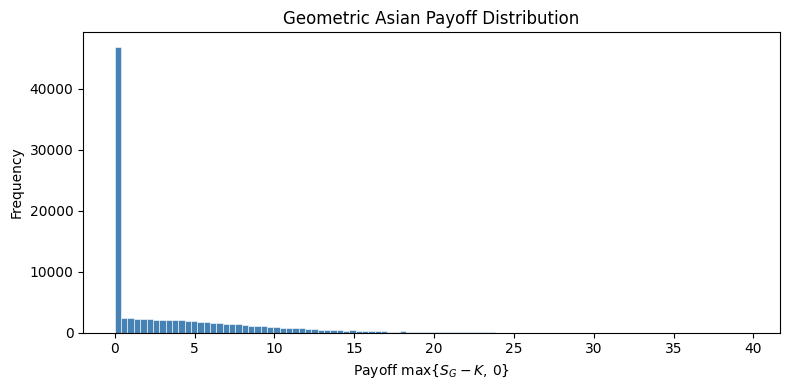

In [5]:
N = 100_000
K = 50
T = 1
s_0 = 50
r = 0.05
sigma = 0.2
n = 5
d_t = T/n

s_G = np.zeros((N, n))
for i_N in range(N):
    for i_n in range(n):
        s_0_n = s_0 if i_n == 0 else s_G[i_N, i_n-1]
        s_G[i_N, i_n] = s_t_gmb(s_0=s_0_n, mu=r, sigma=sigma, d_t=d_t)
s_G = gmean(s_G, axis=1)
payoff = np.maximum(s_G - K, 0)

plt.figure(figsize=(8, 4))
plt.hist(payoff, bins=100, color='steelblue', edgecolor='white', linewidth=0.4)
plt.xlabel('Payoff $\\max\\{S_G - K,\\, 0\\}$')
plt.ylabel('Frequency')
plt.title('Geometric Asian Payoff Distribution')
plt.tight_layout()
plt.show()

#### Part c

In [6]:
G_0 = np.exp(-1*r*T) * np.mean(payoff)
G_0

np.float64(3.2573245309601497)

#### Part d

In [7]:
dt = T / n
var_term = (2*n**2 + 3*n + 1) * dt / (6*n)

d = (np.log(s_0 / K) + (r - sigma**2 / 2) * (dt * (n + 1) / 2)) / (sigma * np.sqrt(var_term))

exp_term = np.exp(-r * (dt * (n - 1) / 2) - (sigma**2 / 2) * (dt * (n**2 - 1) / (6 * n)))
C_G = s_0 * exp_term * norm.cdf(d + sigma * np.sqrt(var_term)) - K * np.exp(-r * T) * norm.cdf(d)

print(f"Closed-form C_G:  {C_G:.6f}")
print(f"MC estimate G_0:  {G_0:.6f}")
print(f"Absolute error:   {abs(G_0 - C_G):.6f}")
print(f"Relative error:   {abs(G_0 - C_G) / C_G:.6f}")

Closed-form C_G:  3.247247
MC estimate G_0:  3.257325
Absolute error:   0.010078
Relative error:   0.003103


# Problem 3

Now consider an arithmetic Asian option with the same parameters as in the previous problem.  The value of this option is

$$A_A = e^{-rT}\mathbb{E}\left[\max\{S_A - K,\, 0\}\right],$$

where $S_A$ is defined as above and $\{S_t\}\sim\textrm{GBM}(r, \sigma)$.

## Part a

What method should you use to simulate $S_A$?  Can you get an exact simulation?  Do you have to simulate $S_t$ at any other time besides $T$?

## Part b

Simulate at least 100,000 i.i.d. samples of the payoff $\max\{S_A - K,\, 0\}$.  Plot a histogram of these payoffs.

## Part c

Using your simulations from part (b), estimate the value of the option $A_A$.

### Solution

#### Part a

The price path simulation is identical to Problem 2: simulate $\{S_t\} \sim \text{GBM}(r, \sigma)$ exactly by chaining increments of $\Delta t = T/n$ across the $n$ monitoring times. We must simulate at all $n$ intermediate times, not just $T$.

Unlike the geometric case, there is no closed-form solution for $A_A$. The geometric mean of lognormals is itself lognormal (products of lognormals are lognormal), which makes $\mathbb{E}[\max\{S_G - K, 0\}]$ analytically tractable. The arithmetic mean of lognormals has no known closed-form distribution -- a sum of lognormals does not simplify to any standard family -- so $\mathbb{E}[\max\{S_A - K, 0\}]$ must be estimated via Monte Carlo.

#### Part b

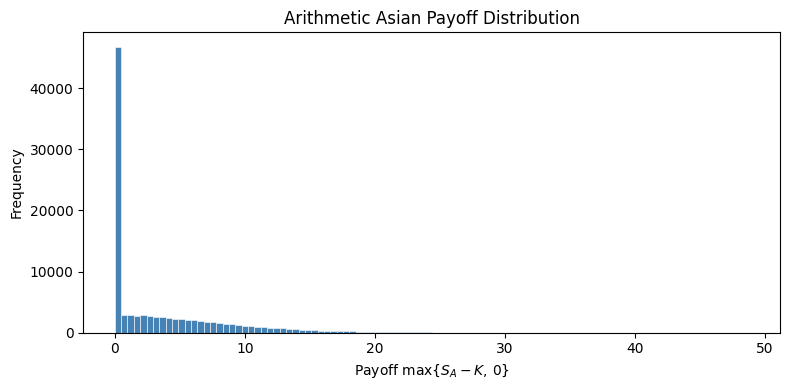

In [8]:
s_A = np.zeros((N, n))
for i_N in range(N):
    for i_n in range(n):
        s_0_n = s_0 if i_n == 0 else s_A[i_N, i_n-1]
        s_A[i_N, i_n] = s_t_gmb(s_0=s_0_n, mu=r, sigma=sigma, d_t=d_t)
s_A = np.mean(s_A, axis=1)
payoff = np.maximum(s_A - K, 0)

plt.figure(figsize=(8, 4))
plt.hist(payoff, bins=100, color='steelblue', edgecolor='white', linewidth=0.4)
plt.xlabel('Payoff $\\max\\{S_A - K,\\, 0\\}$')
plt.ylabel('Frequency')
plt.title('Arithmetic Asian Payoff Distribution')
plt.tight_layout()
plt.show()

#### Part c

In [9]:
A_0 = np.exp(-1*r*T) * np.mean(payoff)
print(f"A_A estimate: {A_0:.6f}")

A_A estimate: 3.348025


# Problem 4

Consider the inhomogeneous Poisson process $\{N_t\}\sim\textrm{Poisson}(\lambda(t))$ with

$$\lambda(t) = t^3 - \frac{21}{2}t^2 + 30t + 1$$

and an initial value of $N_0 = 0$.

## Part a

Use the $\tau$-leaping algorithm to simulate $N_t$ at the times $t = 0$, $t = 1$, $\dotsc$, $t = 6$.  (You should **only** simulate $N_t$ at these seven times.  Do not simulate jump times explicitly.)

Simulate at least $100,000$ i.i.d. sample paths in this way and use them to estimate $\mathbb{E}[N_6]$.  What is the absolute error of your estimate?  What is the relative error?

## Part b

Simulate sample paths of $N_t$ using the thinning algorithm.  (You should simulate every jump time between $t=0$ and $t = 6$.)  Use an optimal value of $\overline{\lambda}$.

Simulate at least $100,000$ i.i.d. sample paths in this way and use them to estimate $\mathbb{E}[N_6]$.  What is the absolute error of your estimate?  What is the relative error?

### Solution
#### Part a

The exact integrated rate over $[s, t]$ is:

$$\Lambda(s, t) = \int_s^t \lambda(u)\, du = \left[\frac{u^4}{4} - \frac{7u^3}{2} + 15u^2 + u\right]_s^t$$

So the true value is $\mathbb{E}[N_6] = \Lambda(0, 6) = 114$.

The $\tau$-leaping algorithm uses the left-endpoint rate $\lambda(t_i)$ over each interval $[t_i, t_{i+1}]$, so it effectively approximates $\Lambda(0,6)$ as a left-endpoint sum: $\sum_{i=0}^{5} \lambda(i) \cdot 1 = 1 + 21.5 + 27 + 23.5 + 17 + 13.5 = 103.5$. This is an inherent discretization bias of the method, not a simulation error -- the large relative error (~9.2%) is expected.

In [10]:
def lam(t):
    return t**3 - (21/2)*(t**2) + 30*t + 1

def big_lam(s, t):
    def x(u):
        return 1/4*u**4 - 7/2*u**3 + 15*u**2 + u
    return x(t) - x(s)

def poisson_inv_cdf(lam, k_max=50):
    u = np.random.uniform(0, 1)
    k = 0
    cdf = np.exp(-lam)
    while cdf < u and k < k_max:
        k += 1
        cdf += np.exp(-lam) * lam**k / factorial(k)
    return k

n_paths = 100_000
N = 6
tau = 1
true_EN6 = big_lam(0, 6)

P = np.zeros((n_paths, N + 1))
for path in range(n_paths):
    for i in range(N):
        delta_N = poisson_inv_cdf(lam=lam(i) * tau)
        P[path, i + 1] = P[path, i] + delta_N

EN6_hat = np.mean(P[:, -1])
print(f"True E[N_6]:      {true_EN6:.4f}")
print(f"MC estimate:      {EN6_hat:.4f}")
print(f"Absolute error:   {abs(EN6_hat - true_EN6):.4f}")
print(f"Relative error:   {abs(EN6_hat - true_EN6) / true_EN6:.6f}")

True E[N_6]:      114.0000
MC estimate:      103.5131
Absolute error:   10.4869
Relative error:   0.091991


#### Part b

To find $\bar{\lambda} = \max_{t \in [0,6]} \lambda(t)$, take the derivative and set to zero:

$$\lambda'(t) = 3t^2 - 21t + 30 = 3(t-2)(t-5)$$

Critical points at $t = 2$ (local max) and $t = 5$ (local min). Evaluating at critical points and endpoints:

| $t$ | $\lambda(t)$ |
|-----|------------|
| 0   | 1          |
| 2   | 27         |
| 5   | 13.5       |
| 6   | 19         |

So $\bar{\lambda} = \lambda(2) = 27$.

**Algorithm:**
- Generate candidate jump times from $\text{Exp}(\bar{\lambda})$: advance $t \mathrel{+}= -\ln(U_1) / \bar{\lambda}$
- At each candidate time $t \leq 6$, draw $U_2 \sim \text{Uniform}(0,1)$; accept the jump (increment $N$) if $U_2 < \lambda(t) / \bar{\lambda}$
- Stop when $t > 6$; record $N_6$

In [11]:
lam_bar = 27
T_end = 6
n_paths = 100_000

N6_samples = np.zeros(n_paths)

for path in range(n_paths):
    t = 0
    N = 0
    while True:
        t += -np.log(np.random.uniform()) / lam_bar
        if t > T_end:
            break
        if np.random.uniform() < lam(t) / lam_bar:
            N += 1
    N6_samples[path] = N

EN6_hat_thin = np.mean(N6_samples)
print(f"True E[N_6]:      {true_EN6:.4f}")
print(f"MC estimate:      {EN6_hat_thin:.4f}")
print(f"Absolute error:   {abs(EN6_hat_thin - true_EN6):.4f}")
print(f"Relative error:   {abs(EN6_hat_thin - true_EN6) / true_EN6:.6f}")

True E[N_6]:      114.0000
MC estimate:      114.0331
Absolute error:   0.0331
Relative error:   0.000291


# Problem 5

Suppose that $X_t$ is a jump diffusion process governed by

$$\textrm{d}X_t = \mu X_t\,\textrm{d}t + \sigma X_t\,\textrm{d}W_t + X_t\,\textrm{d}J_t,$$

where $\{W_t\}\sim\textrm{BM}(0, 1)$ and

$$J_t = \sum_{i = 1}^{N_t}\left(e^{Z_i} - 1\right),$$

with $N_t\sim\textrm{Poisson}(\lambda)$ and the $Z_i\sim N(0, 1)$ are i.i.d. standard normals.

In this problem, we will use $\mu = 0.1$, $\sigma = 0.2$, $\lambda = 0.05$ and $X_0 = 1$.

## Part a

Simulate one trajectory of $\{X_t\}$ from time $t = 0$ to time $t = 6$ using the forward Euler method with 101 evenly spaced time steps.  Plot the trajectory.

## Part b

Using Monte Carlo simulation with a sample size of at least $N = 10,000$, estimate $\mathbb{E}[X_5]$.

### Solution

#### Part a

Simulate $X_t$ using the forward Euler discretization over 101 evenly spaced steps on $[0, 6]$. At each step, draw a Poisson($\lambda \tau$) increment to determine whether a jump occurred. If so, apply the jump term $X_t(e^{Z} - 1)$. The full update is:

$$X_{t+\tau} = X_t + \mu X_t \tau + \sigma X_t \sqrt{\tau}\, Z_1 + X_t(e^{Z_2} - 1)\,\mathbf{1}_{\{\text{jump}\}}$$

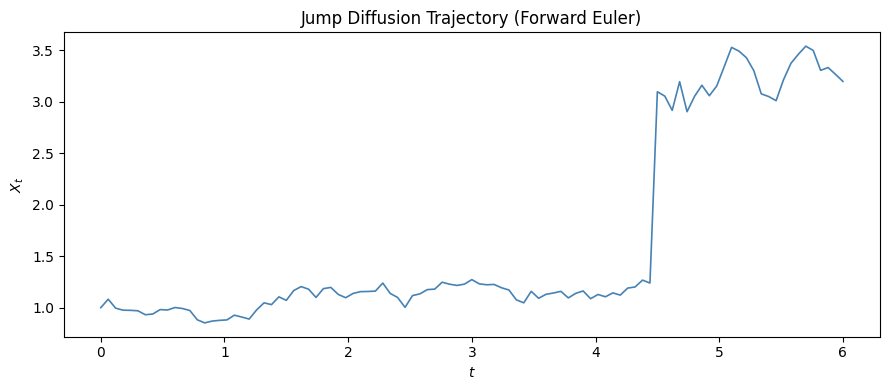

In [12]:
T = 6
n_steps = 101
tau = T / n_steps

mu = 0.1
sigma = 0.2
lam_jd = 0.05
X_0 = 1

X = np.zeros(n_steps)
X[0] = X_0
for i in range(n_steps - 1):
    delta = poisson_inv_cdf(lam=lam_jd * tau)
    if delta > 0:
        J_t = X[i] * (np.exp(np.random.normal()) - 1)
    else:
        J_t = 0
    X[i + 1] = X[i] + mu * X[i] * tau + sigma * X[i] * np.sqrt(tau) * np.random.normal() + J_t

t_grid = np.linspace(0, T, n_steps)
plt.figure(figsize=(9, 4))
plt.plot(t_grid, X, color='steelblue', linewidth=1.2)
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.title('Jump Diffusion Trajectory (Forward Euler)')
plt.tight_layout()
plt.show()

#### Part b

Since $N_t \sim \text{Poisson}(\lambda)$ is a homogeneous Poisson process, inter-arrival times are exactly $\text{Exp}(\lambda)$. Between jumps, $X_t$ follows pure GBM, so the exact Markov kernel applies. At each jump time $\tau_i$, multiply $X$ by $e^{Z_i}$. This gives an exact simulation with no discretization error.

In [13]:
N_mc = 10_000
T_target = 5
mu = 0.1
sigma = 0.2
lam_jd = 0.05
X_0 = 1

X5_samples = np.zeros(N_mc)

for path in range(N_mc):
    t_curr = 0.0
    x = X_0
    t_jump = -np.log(np.random.uniform()) / lam_jd
    while t_jump <= T_target:
        x = s_t_gmb(x, mu, sigma, t_jump - t_curr)
        x *= np.exp(np.random.normal())
        t_curr = t_jump
        t_jump += -np.log(np.random.uniform()) / lam_jd
    x = s_t_gmb(x, mu, sigma, T_target - t_curr)
    X5_samples[path] = x

EX5_hat = np.mean(X5_samples)
print(f"E[X_5] estimate: {EX5_hat:.6f}")

E[X_5] estimate: 2.020818
